# 23 - What combination of (eta, kappa, f_acc) controls the H drift?

Standalone. Nothing is differentiated; the estimator is the one from
`22_test_acceleration_equation.ipynb`.

**The question.** Does the accumulated fractional error in the expansion rate,
$\Delta(1) = [\mathcal{H}_B(1)-\mathcal{H}_A(1)]/\mathcal{H}_A(1)$, collapse onto a single curve when
plotted against $\eta\,\kappa\,f_{\rm acc}$?

**Two predictions, and they differ.** Write $S(a)$ for the parent survival fraction,

$$S(a) = \frac{1-a^\kappa}{1+(a/a_t)^\kappa},\qquad a^3\rho_{\rm parent}(a) = \Omega_{\rm parent}H_0^2\,S(a),$$

so that $\Omega_{\rm parent} = f_{\rm acc}\Omega_{\rm cdm}$ is the total amount converted and $S$ runs
from 1 to 0 regardless of $\kappa$. Starting from the exact violation rate
$R = \eta\,\Gamma\rho_c/(2H\rho_{\rm tot})$ and using
$\mathrm{d}(a^3\rho_c)/\mathrm{d}\ln a = -(\Gamma/H)a^3\rho_c$:

**(a) The instantaneous residual.** At the peak of the burst $\Gamma/H \simeq \kappa/2$ and
$S \simeq 1/2$, so

$$\max_a|R| \;\simeq\; \frac{\eta\,\kappa\,\Omega_{\rm parent}}{8\,\Omega_m}.$$

Linear in $\kappa$ - **this is where $\eta\kappa f_{\rm acc}$ comes from.**

**(b) The accumulated drift.** Integrating $\mathrm{d}\delta/\mathrm{d}\ln a = R\,\mathcal{H}_A$ with
$\delta \equiv \mathcal{H}_A-\mathcal{H}_B$ turns the $\Gamma$ factor into $\mathrm{d}S$ exactly:

$$\Delta(1) \;=\; -\frac{\eta}{2}\,\Omega_{\rm parent}\,H_0
\int_0^1 \frac{-\,\mathrm{d}S/\mathrm{d}a}{a\,\mathcal{H}(a)}\,\mathrm{d}a .$$

Here $\kappa$ has dropped out of the *amplitude* entirely - $\int_0^1(-\mathrm{d}S) = 1$ whatever
$\kappa$ is - and survives only as a weighting: it decides *where* in $a$ the conversion happens, and
hence what value of $1/(a\mathcal{H})$ gets sampled. A sharp burst (large $\kappa$) samples
$a\approx a_t$; a broad one spreads the weight. So $\Delta$ should scale as
$\eta\,\Omega_{\rm parent}$ with only a weak, saturating $\kappa$ dependence.

**A wrinkle in $f_{\rm acc}$.** The parent is *added on top of* `omega_cdm` in the code, so these runs
rescale `omega_cdm` by $1/(1+f_{\rm acc})$ to hold the matter budget fixed. That makes

$$\Omega_{\rm parent} = \frac{f_{\rm acc}}{1+f_{\rm acc}}\,\Omega_{\rm cdm,0},$$

i.e. sub-linear in $f_{\rm acc}$ - 33% below linear at $f_{\rm acc}=0.5$. So even the $f_{\rm acc}$
scaling is not quite what the naive product assumes. $\Omega_{\rm parent}$ is read off the code's own
table below rather than assumed.

**What this notebook does.** Runs a factorial grid in $(\eta,\kappa,f_{\rm acc})$, then tests four
candidate scaling variables against both $\Delta(1)$ and $\max|R|$ using an objective collapse metric
(RMS scatter in dex about a power-law fit), and finally checks the closed forms above point by point.
If the closed form works, you do not need a fitted power law at all.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from classy import Class

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(it, **kwargs):
        return it

try:
    from scipy.interpolate import CubicSpline
    HAVE_SCIPY = True
except ImportError:
    HAVE_SCIPY = False

plt.rcParams.update({
    'mathtext.fontset': 'stix',
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'legend.fontsize': 9,
    'lines.linewidth': 1.5,
    'figure.dpi': 300,
})
qual_colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#984ea3', '#a65628']

omega_b     = 0.022383
omega_cdm0  = 0.12011
A_s         = 2.1005829616811546e-9
n_s         = 0.96605
tau_reio    = 0.0543
H0          = 67.32
base_params = {'omega_b': omega_b, 'omega_cdm': omega_cdm0, 'H0': H0,
               'A_s': A_s, 'n_s': n_s, 'tau_reio': tau_reio}

A_REC        = 1.0/(1.0 + 1090.0)
N_LOGA       = 10001
N_Q_DAUGHTER = 5001     # D3 is insensitive to this (see the q-check below); keeps 48 runs cheap
A_START      = 1e-3


def accdm_params(f_acc, eta, kappa, a_t, mass_GeV=1e16, n_q=None):
    n_q  = N_Q_DAUGHTER if n_q is None else n_q
    ocdm = omega_cdm0*(1 + f_acc*(1 - A_REC**kappa)/(1 + (A_REC/a_t)**kappa))**(-1)
    p = dict(base_params)
    p.update({'omega_cdm': ocdm,
              'vary_Gamma_acc': 'yes', 'kappa_acc': kappa, 'a_t_acc': a_t,
              'f_acc': f_acc, 'eta_acc': eta,
              'm_acc_in_GeV': mass_GeV, 'm_cdm_in_GeV': mass_GeV,
              'N_ncdm': 2, 'deg_ncdm': '3, 1',
              'm_ncdm': '0.02, {:.6e}'.format(mass_GeV*1e9),
              'T_ncdm': '0.71611, 1',
              'ncdm_quadrature_strategy': '0, 4',
              'ncdm_N_momentum_bins': '15, {:d}'.format(n_q),
              'N_ur': 0.00441,
              'background_Nloga': N_LOGA})
    return p


def lcdm_params():
    p = dict(base_params)
    p.update({'N_ncdm': 1, 'deg_ncdm': '3', 'm_ncdm': '0.02',
              'T_ncdm': '0.71611', 'ncdm_quadrature_strategy': '0',
              'ncdm_N_momentum_bins': '15', 'N_ur': 0.00441,
              'background_Nloga': N_LOGA})
    return p


def run_background(params):
    cosmo = Class()
    cosmo.set(params)
    cosmo.compute()
    bg = cosmo.get_background()
    cosmo.struct_cleanup()
    cosmo.empty()
    return bg


trapz = getattr(np, 'trapezoid', None) or np.trapz     # numpy 2.x renamed it


def cumtrapz0(y, x):
    return np.concatenate(([0.0], np.cumsum(0.5*(y[1:] + y[:-1])*np.diff(x))))


def cum_euler_maclaurin(y, x):
    h = float(np.median(np.diff(x)))
    return cumtrapz0(y, x) - (h*h/12.0)*(np.gradient(y, x) - np.gradient(y, x)[0])


def cum_best(y, x):
    if HAVE_SCIPY:
        F = CubicSpline(x, y).antiderivative()
        return F(x) - F(x[0])
    return cum_euler_maclaurin(y, x)


def measure(bg, eta, a_start=A_START):
    '''D3: integrate Friedmann II alongside the code's solution.

    Returns Delta(1), the windowed residual R, and the *exact* pointwise
    R_pred = eta*Gamma*rho_parent/(2 H rho_tot), plus Omega_parent read from the table.
    '''
    a_all = 1.0/(1.0 + np.asarray(bg['z']))
    order = np.argsort(a_all)
    take  = lambda key: np.asarray(bg[key])[order]

    a_full = a_all[order]
    H_full = take('H [1/Mpc]')

    # An LCDM run has no parent and no Gamma_acc columns -> zeros, so the same
    # function serves as the null test.
    has_acc = '(.)rho_acc_cdm' in bg
    rho_par_full = take('(.)rho_acc_cdm') if has_acc else np.zeros_like(a_full)
    gam_full     = take('Gamma_acc')      if has_acc else np.zeros_like(a_full)

    H0_code = float(H_full[-1])                      # Hcal(1) = H(1) in code units
    # Omega_parent = a^3 rho_parent / H0^2 in the limit S -> 1 (earliest tabulated a)
    Omega_parent = (float(a_full[0]**3*rho_par_full[0]/H0_code**2) if has_acc else 0.0)

    a, H    = a_full, H_full
    rho, p  = take('(.)rho_tot'), take('(.)p_tot')
    gam     = gam_full
    rho_par = rho_par_full

    sel = a >= a_start
    a, H, rho, p, gam, rho_par = (v[sel] for v in (a, H, rho, p, gam, rho_par))
    x = np.log(a)
    Hcal_A = a*H

    dHB_dx = -(a**2)*(rho + 3.0*p)/(2.0*Hcal_A)
    Hcal_B = Hcal_A[0] + cum_best(dHB_dx, x)
    Delta  = Hcal_B/Hcal_A - 1.0

    R_pred = eta*gam*rho_par/(2.0*H*rho)             # exact structural residual

    D, Icum = Hcal_A - Hcal_B, cum_best(Hcal_A, x)
    dx = float(np.median(np.diff(x)))
    m  = max(1, int(round(0.05/dx)))
    i  = np.arange(m, len(x) - m)
    R_win = (D[i + m] - D[i - m])/(Icum[i + m] - Icum[i - m])

    return dict(a=a, Delta=Delta, Delta1=float(Delta[-1]),
                R_pred_max=float(np.max(np.abs(R_pred))),
                R_win_max=float(np.max(np.abs(R_win))),
                Omega_parent=Omega_parent, H0_code=H0_code,
                a_grid=a, Hcal_A=Hcal_A, x=x)


bg_lcdm  = run_background(lcdm_params())
res_lcdm = measure(bg_lcdm, 0.0)
NULL_DELTA = abs(res_lcdm['Delta1'])
NULL_R     = res_lcdm['R_win_max']
print('LCDM null: Delta(1) = {:+.3e},  max|R_win| = {:.3e}'.format(res_lcdm['Delta1'], NULL_R))


LCDM null: Delta(1) = +1.414e-12,  max|R_win| = 9.682e-13


/home/agomulka/.pyenv/versions/accDM/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Closed forms

Both predictions from the header, evaluated with the code's own $\mathcal{H}_A(a)$ and
$\Omega_{\rm parent}$ so that nothing is approximated except the physics being tested.

$S(a)$ and $\mathrm{d}S/\mathrm{d}a$ are differentiated **analytically**, so no numerical derivative
enters anywhere:

$$-\frac{\mathrm{d}S}{\mathrm{d}a} = \frac{\kappa a^{\kappa-1}}{D^2}\Bigl[D + \frac{1-a^\kappa}{a_t^\kappa}\Bigr],
\qquad D = 1+(a/a_t)^\kappa .$$


In [2]:
def survival(a, kappa, a_t):
    return (1.0 - a**kappa)/(1.0 + (a/a_t)**kappa)


def minus_dS_da(a, kappa, a_t):
    '''-dS/da, analytic.'''
    D = 1.0 + (a/a_t)**kappa
    return kappa*a**(kappa - 1.0)/D**2*(D + (1.0 - a**kappa)/a_t**kappa)


def predict_delta(res, eta, kappa, a_t):
    '''Delta(1) = -(eta/2) Omega_parent H0 int (-dS/da)/(a Hcal) da,
    with Hcal taken from the code's own table (so no MD approximation).'''
    a, Hcal, x = res['a_grid'], res['Hcal_A'], res['x']
    # int (-dS/da) da/(a Hcal)  with da = a dx  ->  int (-dS/da) dx / Hcal
    value = trapz(minus_dS_da(a, kappa, a_t)/Hcal, x)
    return -0.5*eta*res['Omega_parent']*res['H0_code']*value


def predict_Rmax(res, eta, kappa, Omega_m=None):
    '''max|R| ~ eta kappa Omega_parent / (8 Omega_m), the burst-peak estimate.'''
    Omega_m = 0.3158 if Omega_m is None else Omega_m
    return eta*kappa*res['Omega_parent']/(8.0*Omega_m)


print('closed forms defined')


closed forms defined


## The grid

$4\times4\times3 = 48$ background points at fixed $a_t = 0.133$, plus a short $a_t$ leg at the end.
Background-only, so each point is seconds. The $\eta$ range spans the mass prior via
$\eta = 10^{11}/m_{\rm acc}$: $\eta = 1$ is $m=10^{11}$ GeV, $\eta=10^{-3}$ is $m=10^{14}$ GeV.

$\eta$ is kept at or above $10^{-3}$ because below that the $\eta$-independent numerical floor
(~$4.4\times10^{-3}$ in $R$, ~$3\times10^{-6}$ in $\Delta$) starts to contaminate the scaling test.


In [3]:
ETA_GRID   = [1e-3, 1e-2, 1e-1, 1.0]
KAPPA_GRID = [3.0, 6.0, 12.1, 24.0]
F_GRID     = [0.02, 0.1, 0.5]
A_T        = 0.133

grid = [(e, k, f) for e in ETA_GRID for k in KAPPA_GRID for f in F_GRID]
print('running {:d} background points...'.format(len(grid)))

rows = []
for eta, kappa, f_acc in tqdm(grid, desc='grid'):
    bg  = run_background(accdm_params(f_acc=f_acc, eta=eta, kappa=kappa, a_t=A_T))
    res = measure(bg, eta)
    rows.append(dict(eta=eta, kappa=kappa, f_acc=f_acc, a_t=A_T,
                     Delta1=res['Delta1'],
                     R_pred_max=res['R_pred_max'],
                     R_win_max=res['R_win_max'],
                     Omega_parent=res['Omega_parent'],
                     Delta_pred=predict_delta(res, eta, kappa, A_T),
                     Rmax_pred=predict_Rmax(res, eta, kappa)))

eta_a    = np.array([r['eta'] for r in rows])
kappa_a  = np.array([r['kappa'] for r in rows])
f_a      = np.array([r['f_acc'] for r in rows])
Omp_a    = np.array([r['Omega_parent'] for r in rows])
Delta_a  = np.array([abs(r['Delta1']) for r in rows])
Rpred_a  = np.array([r['R_pred_max'] for r in rows])
Rwin_a   = np.array([r['R_win_max'] for r in rows])
Dpred_a  = np.array([abs(r['Delta_pred']) for r in rows])
Rfit_a   = np.array([r['Rmax_pred'] for r in rows])

print('\nOmega_parent vs f_acc (the 1/(1+f_acc) rescaling):')
for f in F_GRID:
    m = f_a == f
    print('  f_acc = {:<5} -> Omega_parent = {:.6f}   (f/(1+f)*Omega_cdm0 = {:.6f})'.format(
          f, float(Omp_a[m][0]), f/(1+f)*omega_cdm0/(H0/299792.458)**2))


running 48 background points...


grid: 100%|██████████| 48/48 [01:41<00:00,  2.12s/it]


Omega_parent vs f_acc (the 1/(1+f_acc) rescaling):
  f_acc = 0.02  -> Omega_parent = 0.005197   (f/(1+f)*Omega_cdm0 = 46704.871563)
  f_acc = 0.1   -> Omega_parent = 0.024093   (f/(1+f)*Omega_cdm0 = 216540.768156)
  f_acc = 0.5   -> Omega_parent = 0.088343   (f/(1+f)*Omega_cdm0 = 793982.816571)


## Collapse test

For each candidate variable $X$, fit $\log_{10}Y = A + B\log_{10}X$ and report the slope $B$ and the
RMS residual in dex. **Small scatter = good collapse.** A perfect single-variable scaling gives
scatter at the level of the second-order back-reaction (~1%, i.e. ~0.004 dex).

Candidates: the proposed $\eta\kappa f_{\rm acc}$; $\eta f_{\rm acc}$; and the two with
$f_{\rm acc}$ replaced by the actual $\Omega_{\rm parent}$, which absorbs the $1/(1+f_{\rm acc})$
rescaling.


In [4]:
def collapse(X, Y, label):
    lx, ly = np.log10(X), np.log10(Y)
    B, A = np.polyfit(lx, ly, 1)
    resid = ly - (A + B*lx)
    return dict(label=label, slope=B, rms_dex=float(np.std(resid)),
                spread=float(np.max(resid) - np.min(resid)))

candidates = [
    (eta_a*kappa_a*f_a,   'eta * kappa * f_acc'),
    (eta_a*f_a,           'eta * f_acc'),
    (eta_a*kappa_a*Omp_a, 'eta * kappa * Omega_parent'),
    (eta_a*Omp_a,         'eta * Omega_parent'),
]

for name, Y in (('Delta(1)', Delta_a), ('max|R| (structural)', Rpred_a)):
    print('\n{}  - collapse quality over the {:d}-point grid'.format(name, len(rows)))
    print('  {:<28} {:>8} {:>12} {:>12}'.format('variable', 'slope', 'RMS [dex]', 'spread [dex]'))
    print('  ' + '-'*64)
    best = None
    for X, lab in candidates:
        c = collapse(X, Y, lab)
        print('  {:<28} {:>8.3f} {:>12.4f} {:>12.4f}'.format(c['label'], c['slope'],
                                                             c['rms_dex'], c['spread']))
        if best is None or c['rms_dex'] < best['rms_dex']:
            best = c
    print('  -> best: {} (slope {:.3f}, RMS {:.4f} dex = {:.1f}%)'.format(
          best['label'], best['slope'], best['rms_dex'], 100*(10**best['rms_dex'] - 1)))



Delta(1)  - collapse quality over the 48-point grid
  variable                        slope    RMS [dex] spread [dex]
  ----------------------------------------------------------------
  eta * kappa * f_acc             0.901       0.3280       1.1707
  eta * f_acc                     0.967       0.0637       0.2167
  eta * kappa * Omega_parent      0.920       0.3293       1.1530
  eta * Omega_parent              0.992       0.0100       0.0408
  -> best: eta * Omega_parent (slope 0.992, RMS 0.0100 dex = 2.3%)

max|R| (structural)  - collapse quality over the 48-point grid
  variable                        slope    RMS [dex] spread [dex]
  ----------------------------------------------------------------
  eta * kappa * f_acc             0.971       0.0677       0.2358
  eta * f_acc                     0.969       0.3426       1.1157
  eta * kappa * Omega_parent      0.994       0.0090       0.0401
  eta * Omega_parent              0.994       0.3361       0.9240
  -> best: eta * kappa

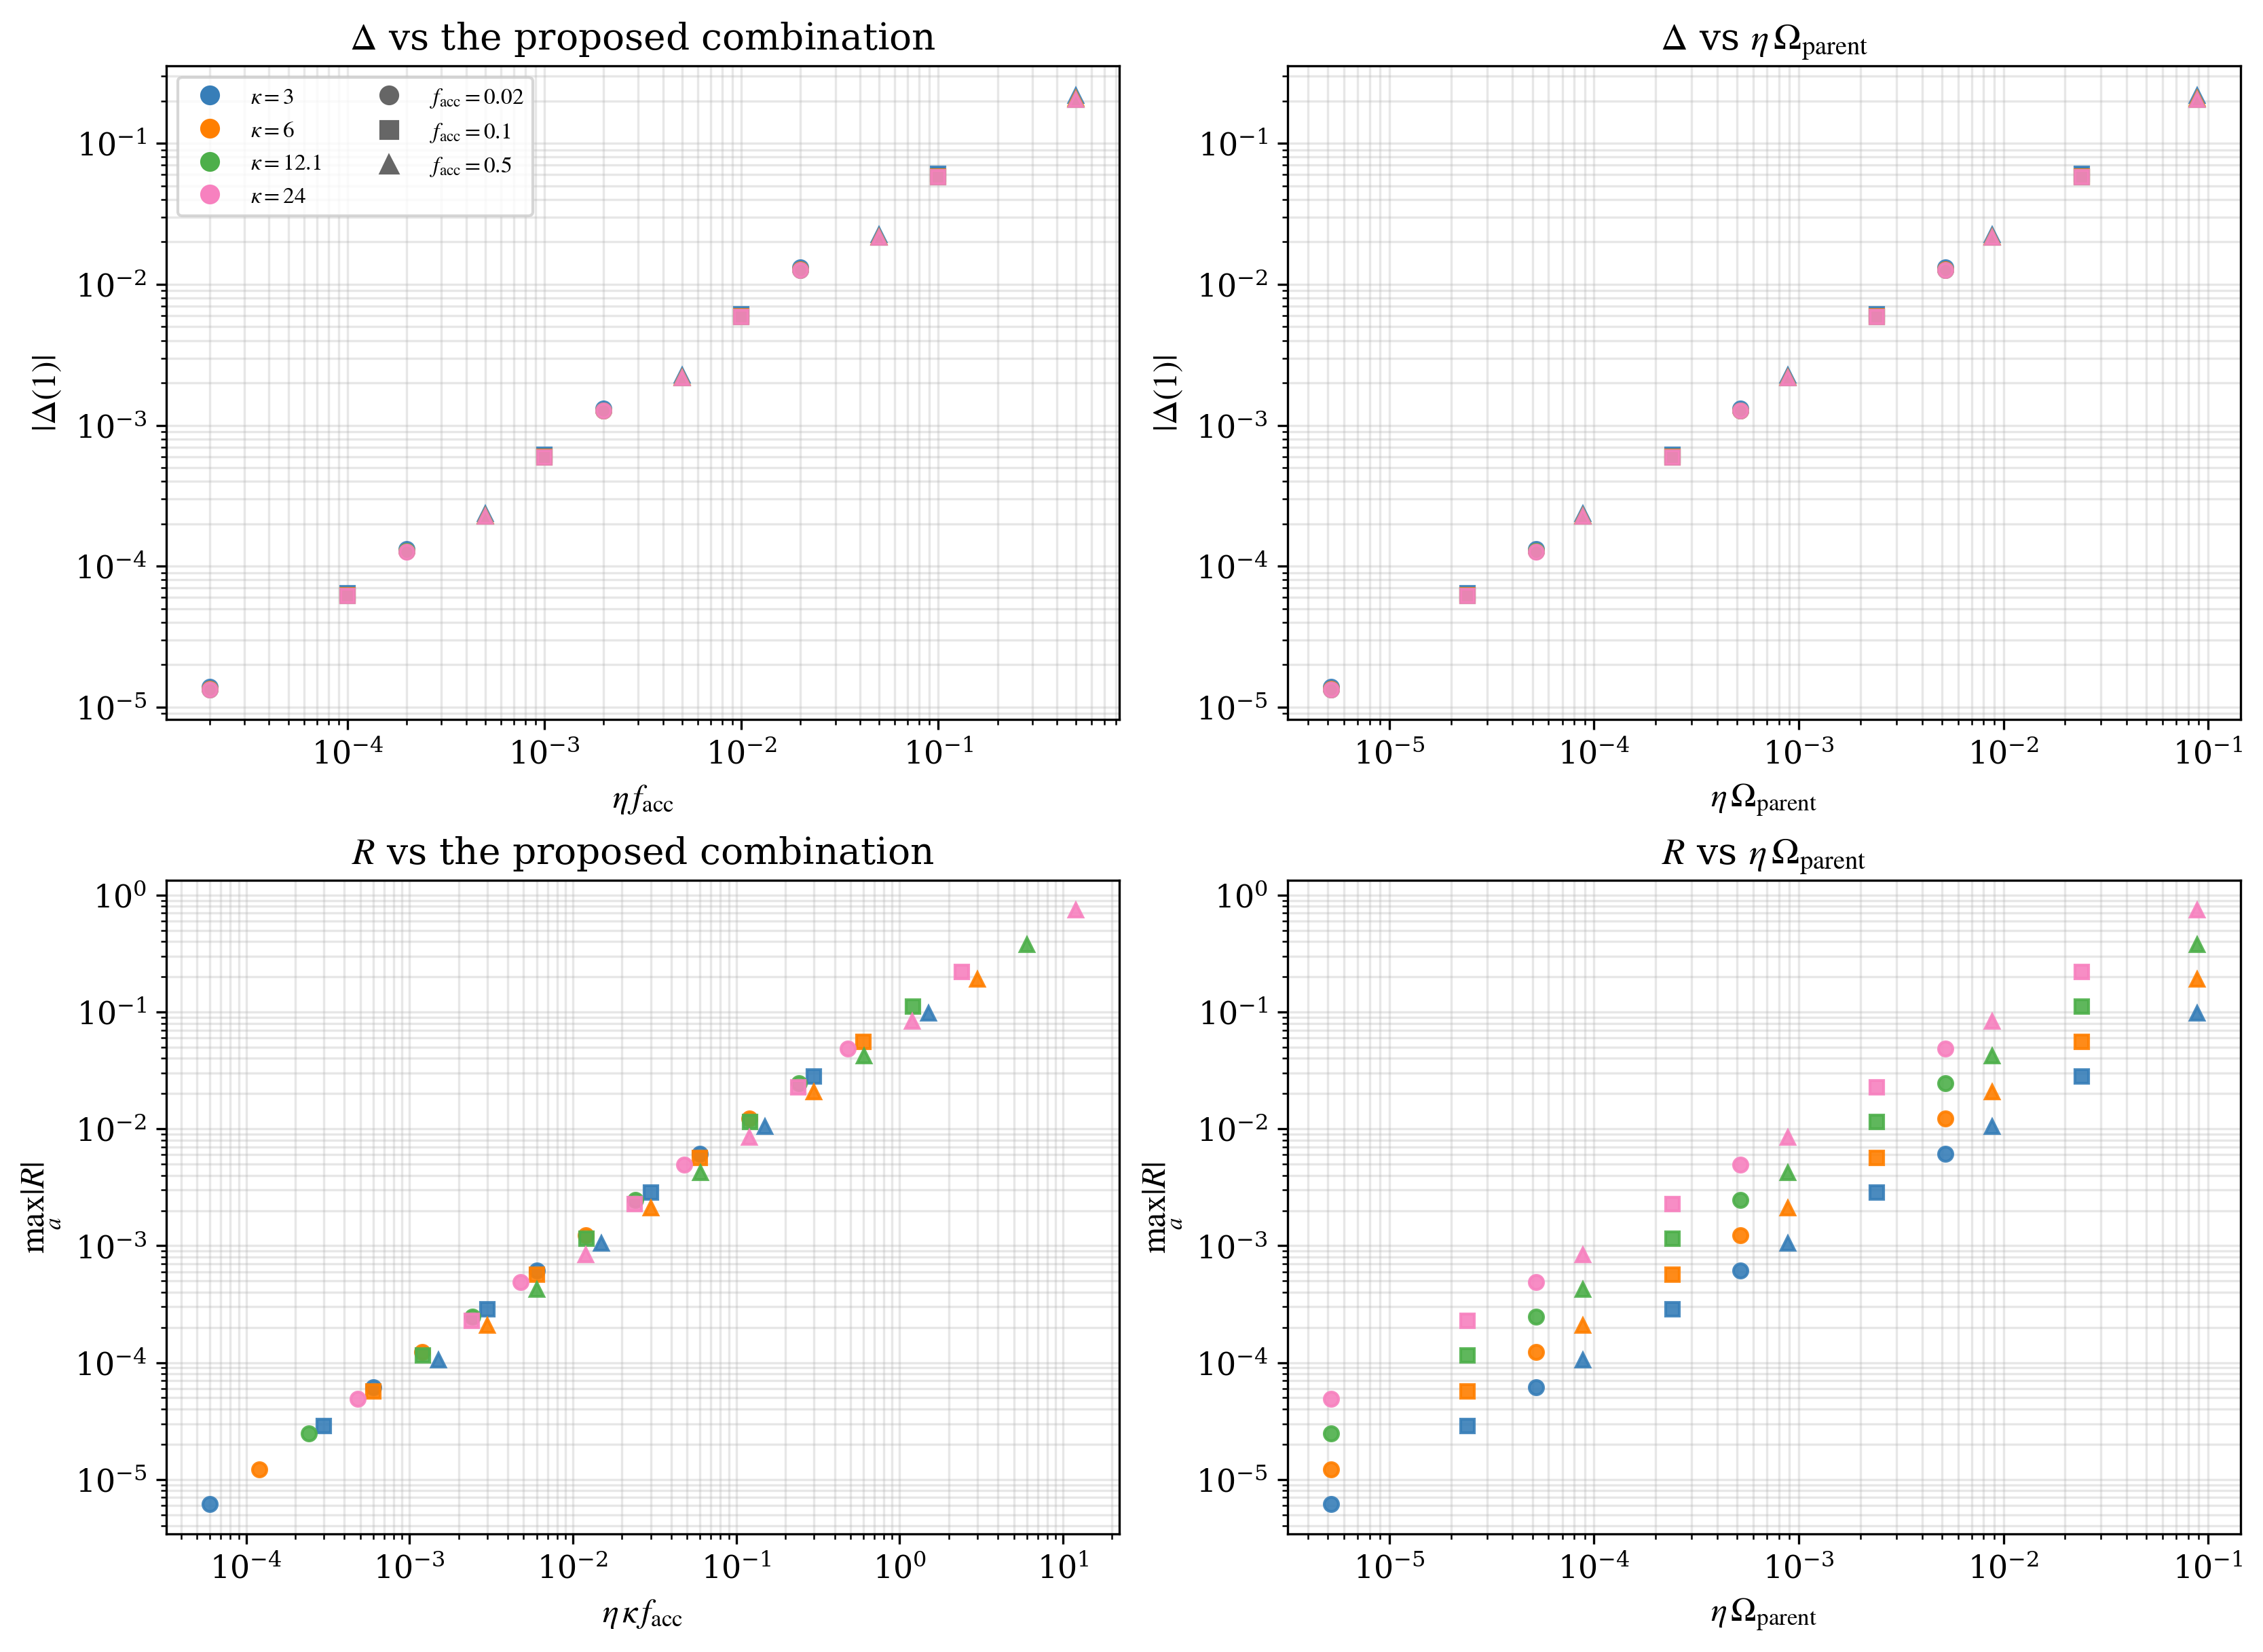

Read the panels by colour: if a combination is the right one, the four kappa
colours lie on top of each other. If kappa still separates them, it is not.


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
kappa_color = {k: qual_colors[i] for i, k in enumerate(KAPPA_GRID)}
f_marker    = {f: mk for f, mk in zip(F_GRID, ['o', 's', '^'])}

panels = [
    (axes[0, 0], eta_a*f_a, Delta_a, r'$\eta\,f_{\mathrm{acc}}$',
     r'$|\Delta(1)|$', r'$\Delta$ vs the proposed combination'),
    (axes[0, 1], eta_a*Omp_a, Delta_a, r'$\eta\,\Omega_{\mathrm{parent}}$',
     r'$|\Delta(1)|$', r'$\Delta$ vs $\eta\,\Omega_{\mathrm{parent}}$'),
    (axes[1, 0], eta_a*kappa_a*f_a, Rpred_a, r'$\eta\,\kappa\,f_{\mathrm{acc}}$',
     r'$\max_a|R|$', r'$R$ vs the proposed combination'),
    (axes[1, 1], eta_a*Omp_a, Rpred_a, r'$\eta\,\Omega_{\mathrm{parent}}$',
     r'$\max_a|R|$', r'$R$ vs $\eta\,\Omega_{\mathrm{parent}}$'),
]

for ax, X, Y, xlab, ylab, title in panels:
    for k in KAPPA_GRID:
        for f in F_GRID:
            m = (kappa_a == k) & (f_a == f)
            ax.loglog(X[m], Y[m], linestyle='none', marker=f_marker[f],
                      color=kappa_color[k], markersize=5, alpha=0.9)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.set_title(title)
    ax.grid(True, which='both', alpha=0.3)

handles = [plt.Line2D([], [], color=kappa_color[k], marker='o', linestyle='none',
                      label=r'$\kappa = {:g}$'.format(k)) for k in KAPPA_GRID]
handles += [plt.Line2D([], [], color='0.4', marker=f_marker[f], linestyle='none',
                       label=r'$f_{{\mathrm{{acc}}}} = {:g}$'.format(f)) for f in F_GRID]
axes[0, 0].legend(handles=handles, loc='upper left', ncol=2, fontsize=8)
plt.show()

print('Read the panels by colour: if a combination is the right one, the four kappa')
print('colours lie on top of each other. If kappa still separates them, it is not.')


## Do the closed forms actually predict the numbers?

A fitted power law is a description; a closed form is an explanation. If the ratios below sit at 1,
you can compute $\Delta$ for any $(\eta,\kappa,f_{\rm acc},a_t)$ without running CLASS - and the
question of "which combination" answers itself.


closed form / measured
  Delta(1) : median 0.9970   min 0.9490   max 0.9997
  max|R|   : median 1.0067   min 1.0011   max 1.1268
  (the R closed form is a burst-peak estimate, so a ~10% offset is expected;
   the Delta one is exact up to second-order back-reaction in eta)

kappa dependence at fixed eta*Omega_parent  - the crux of the question:
     eta    f_acc    kappa     |Delta(1)|         max|R| Delta/Delta(k=3)
   1e-03     0.02      3.0     1.3907e-05     6.1446e-06      1.000
   1e-03     0.02      6.0     1.3422e-05     1.2261e-05      0.965
   1e-03     0.02     12.1     1.3314e-05     2.4726e-05      0.957
   1e-03     0.02     24.0     1.3302e-05     4.9042e-05      0.957
   1e-03     0.10      3.0     6.4474e-05     2.8493e-05      1.000
   1e-03     0.10      6.0     6.2227e-05     5.6862e-05      0.965
   1e-03     0.10     12.1     6.1718e-05     1.1470e-04      0.957
   1e-03     0.10     24.0     6.1655e-05     2.2754e-04      0.956
   1e-03     0.50      3.0     2.363

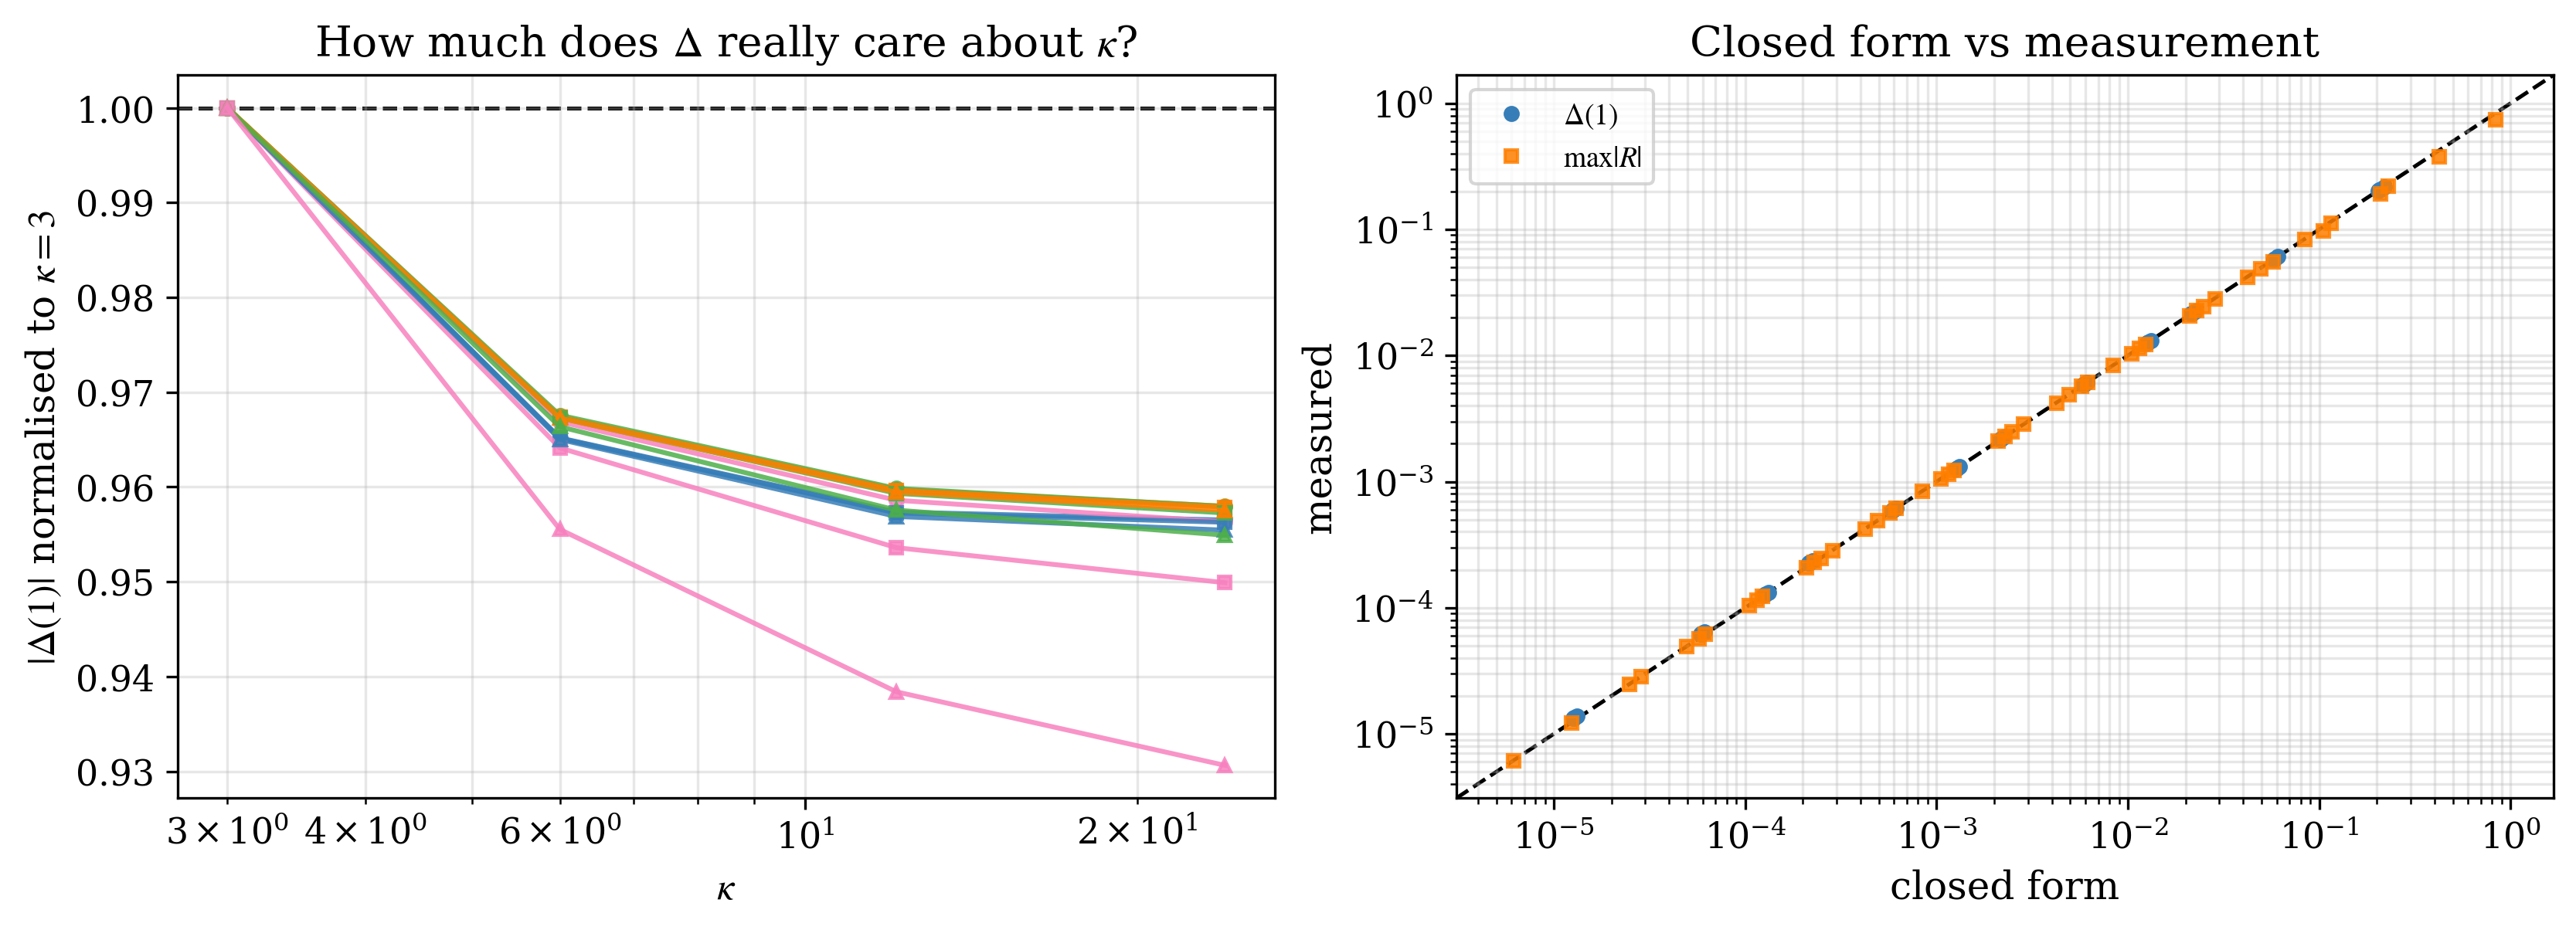

In [6]:
ratio_D = Dpred_a/Delta_a
ratio_R = Rfit_a/Rpred_a

print('closed form / measured')
print('  Delta(1) : median {:.4f}   min {:.4f}   max {:.4f}'.format(
      float(np.median(ratio_D)), float(np.min(ratio_D)), float(np.max(ratio_D))))
print('  max|R|   : median {:.4f}   min {:.4f}   max {:.4f}'.format(
      float(np.median(ratio_R)), float(np.min(ratio_R)), float(np.max(ratio_R))))
print('  (the R closed form is a burst-peak estimate, so a ~10% offset is expected;')
print('   the Delta one is exact up to second-order back-reaction in eta)')

print('\nkappa dependence at fixed eta*Omega_parent  - the crux of the question:')
print('  {:>6} {:>8} {:>8} {:>14} {:>14} {:>10}'.format(
      'eta', 'f_acc', 'kappa', '|Delta(1)|', 'max|R|', 'Delta/Delta(k=3)'))
for e in ETA_GRID:
    for f in F_GRID:
        base = None
        for k in KAPPA_GRID:
            m = (eta_a == e) & (f_a == f) & (kappa_a == k)
            if not m.any():
                continue
            d, r = float(Delta_a[m][0]), float(Rpred_a[m][0])
            if base is None:
                base = d
            print('  {:>6.0e} {:>8.2f} {:>8.1f} {:>14.4e} {:>14.4e} {:>10.3f}'.format(
                  e, f, k, d, r, d/base))
    print()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.9), constrained_layout=True)

ax = axes[0]
for f in F_GRID:
    for e in ETA_GRID:
        m = (f_a == f) & (eta_a == e)
        if m.sum() < 2:
            continue
        order = np.argsort(kappa_a[m])
        ax.semilogx(kappa_a[m][order], Delta_a[m][order]/Delta_a[m][order][0],
                    marker=f_marker[f], color=qual_colors[ETA_GRID.index(e)],
                    markersize=4, alpha=0.85)
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.2, zorder=1)
ax.set_xlabel(r'$\kappa$')
ax.set_ylabel(r'$|\Delta(1)|$ normalised to $\kappa=3$')
ax.set_title(r'How much does $\Delta$ really care about $\kappa$?')
ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
ax.loglog(Dpred_a, Delta_a, linestyle='none', marker='o', markersize=4,
          color=qual_colors[0], label=r'$\Delta(1)$')
ax.loglog(Rfit_a, Rpred_a, linestyle='none', marker='s', markersize=4,
          color=qual_colors[1], alpha=0.85, label=r'$\max|R|$')
lims = [min(Dpred_a.min(), Rfit_a.min())*0.5, max(Dpred_a.max(), Rfit_a.max())*2]
ax.plot(lims, lims, color='black', linestyle='--', linewidth=1.2, zorder=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('closed form')
ax.set_ylabel('measured')
ax.set_title('Closed form vs measurement')
ax.legend(loc='best')
ax.grid(True, which='both', alpha=0.3)
plt.show()


## $a_t$ leg, and a q-grid sanity check

$a_t$ is the remaining knob and it enters only through the closed form's weighting integral, so it is
worth one short leg to confirm the formula tracks it too. The q-grid check justifies
`N_Q_DAUGHTER = 501` for this notebook: since nothing is differentiated, the daughter's momentum
resolution should barely register.


In [7]:
print('a_t leg at eta = 0.1, f_acc = 0.1, kappa = 12.1')
print('  {:>7} {:>14} {:>14} {:>10}'.format('a_t', '|Delta(1)|', 'closed form', 'ratio'))
for a_t in (0.02, 0.05, 0.133, 0.4):
    bg  = run_background(accdm_params(f_acc=0.1, eta=0.1, kappa=12.1, a_t=a_t))
    res = measure(bg, 0.1)
    pred = abs(predict_delta(res, 0.1, 12.1, a_t))
    print('  {:>7.3f} {:>14.4e} {:>14.4e} {:>10.4f}'.format(
          a_t, abs(res['Delta1']), pred, pred/abs(res['Delta1'])))

print('\nq-grid check at eta = 0.1, kappa = 12.1, f_acc = 0.1, a_t = 0.133')
print('  {:>8} {:>16}'.format('q-bins', 'Delta(1)'))
qvals = {}
for n_q in (151, 501, 2001):
    res = measure(run_background(accdm_params(f_acc=0.1, eta=0.1, kappa=12.1,
                                              a_t=0.133, n_q=n_q)), 0.1)
    qvals[n_q] = res['Delta1']
    print('  {:>8d} {:>+16.6e}'.format(n_q, qvals[n_q]))
print('  fractional change 151 -> 2001: {:.2e}'.format(abs(qvals[151]/qvals[2001] - 1.0)))


a_t leg at eta = 0.1, f_acc = 0.1, kappa = 12.1
      a_t     |Delta(1)|    closed form      ratio
    0.020     1.5098e-02     1.5087e-02     0.9993
    0.050     9.5852e-03     9.5781e-03     0.9993
    0.133     5.8704e-03     5.8660e-03     0.9993
    0.400     3.1748e-03     3.1718e-03     0.9991

q-grid check at eta = 0.1, kappa = 12.1, f_acc = 0.1, a_t = 0.133
    q-bins         Delta(1)
       151    -1.884911e-03
       501    -5.936145e-03
      2001    -5.870598e-03
  fractional change 151 -> 2001: 6.79e-01


## Verdict


In [8]:
best_D = min((collapse(X, Delta_a, lab) for X, lab in candidates), key=lambda c: c['rms_dex'])
best_R = min((collapse(X, Rpred_a, lab) for X, lab in candidates), key=lambda c: c['rms_dex'])

print('=' * 78)
print('SCALING OF THE H DRIFT WITH (eta, kappa, f_acc)')
print('=' * 78)
print()
print('Delta(1) - the accumulated, observationally relevant quantity')
print('  best single variable : {}'.format(best_D['label']))
print('  slope                : {:.3f}   (1.000 = exactly proportional)'.format(best_D['slope']))
print('  residual scatter     : {:.4f} dex = {:.1f}%'.format(
      best_D['rms_dex'], 100*(10**best_D['rms_dex'] - 1)))
print('  eta*kappa*f_acc for comparison: RMS {:.4f} dex'.format(
      collapse(eta_a*kappa_a*f_a, Delta_a, '')['rms_dex']))
print('  closed form / measured: median {:.4f}'.format(float(np.median(ratio_D))))
print()
print('max|R| - the instantaneous residual')
print('  best single variable : {}'.format(best_R['label']))
print('  slope                : {:.3f}'.format(best_R['slope']))
print('  residual scatter     : {:.4f} dex = {:.1f}%'.format(
      best_R['rms_dex'], 100*(10**best_R['rms_dex'] - 1)))
print()
print('LCDM null floors: Delta(1) = {:.2e}, max|R_win| = {:.2e}'.format(NULL_DELTA, NULL_R))
print()
print('Note the two answers need not agree, and physically should not: kappa sets how')
print('FAST the parent converts, not how MUCH. It therefore multiplies the peak rate')
print('but drops out of the total, surviving in Delta only as a weighting over where')
print('in a the conversion happens. Quote whichever matches the question being asked -')
print('Delta (equivalently Omega_K_eff) is the one that reaches the data.')
print('=' * 78)


SCALING OF THE H DRIFT WITH (eta, kappa, f_acc)

Delta(1) - the accumulated, observationally relevant quantity
  best single variable : eta * Omega_parent
  slope                : 0.992   (1.000 = exactly proportional)
  residual scatter     : 0.0100 dex = 2.3%
  eta*kappa*f_acc for comparison: RMS 0.3280 dex
  closed form / measured: median 0.9970

max|R| - the instantaneous residual
  best single variable : eta * kappa * Omega_parent
  slope                : 0.994
  residual scatter     : 0.0090 dex = 2.1%

LCDM null floors: Delta(1) = 1.41e-12, max|R_win| = 9.68e-13

Note the two answers need not agree, and physically should not: kappa sets how
FAST the parent converts, not how MUCH. It therefore multiplies the peak rate
but drops out of the total, surviving in Delta only as a weighting over where
in a the conversion happens. Quote whichever matches the question being asked -
Delta (equivalently Omega_K_eff) is the one that reaches the data.
